In [1]:
import numpy as np
import chess
import chess.pgn
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# datos tomados del train
ELO_MIN = 1000 
ELO_MAX = 3390
ELO_MEAN = 2028.3
ELO_STD = 593.4
ELO_MEDIAN = 2028.0
ELO_Q1 = 1514.0
ELO_Q3 = 2538.0 
ELO_IQR = ELO_Q3 - ELO_Q1


In [3]:
def normalizar_elo(elo, metodo):
    """Aplica la normalización elegida."""
    if metodo == "minmax":
        # Rango [0, 1]
        return (elo - ELO_MIN) / (ELO_MAX - ELO_MIN)
    elif metodo == "standard":
        # Centrado en 0, desvío 1 (Z-score)
        return (elo - ELO_MEAN) / ELO_STD
    elif metodo == "robust":
        # Resistente a valores atípicos (outliers)
        return (elo - ELO_MEDIAN) / ELO_IQR
    else: # "none" o error
        return elo

In [4]:
def board_to_bitboard_vector_13(board):
    """Convierte un chess.Board a un vector binario de 832 bits (13 x 64)."""
    piece_types = [
        (chess.PAWN, chess.WHITE), (chess.PAWN, chess.BLACK),
        (chess.ROOK, chess.WHITE), (chess.ROOK, chess.BLACK),
        (chess.KNIGHT, chess.WHITE), (chess.KNIGHT, chess.BLACK),
        (chess.BISHOP, chess.WHITE), (chess.BISHOP, chess.BLACK),
        (chess.QUEEN, chess.WHITE), (chess.QUEEN, chess.BLACK),
        (chess.KING, chess.WHITE), (chess.KING, chess.BLACK),
    ]

    vec = np.zeros(13 * 64, dtype=np.int8)

    # Llenamos los 12 primeros bitboards
    for i, (piece, color) in enumerate(piece_types):
        bitboard = board.pieces(piece, color)
        for square in bitboard:
            vec[i * 64 + square] = 1

    # Bitboard 13: casillas vacías
    occupied = board.occupied
    for square in chess.SQUARES:
        if not occupied & chess.BB_SQUARES[square]:
            vec[12 * 64 + square] = 1

    return vec

In [5]:
def preprocesar_pgn_a_npz(pgn_filename, out_filename,ply_numbers):
    print(f"Preprocesando {pgn_filename} -> {out_filename}")
    X_list = []
    # Creamos listas separadas para cada tipo de Elo
    y_raw = []
    y_minmax = []
    y_standard = []
    y_robust = []
    game_indices = []
    idx_partida = -1
    errores = 0

    max_ply = max(ply_numbers)
    
    with open(pgn_filename, "r", encoding="utf-8") as f:
        with tqdm(desc="Partidas procesadas") as pbar:
            while True:
                try:
                    game = chess.pgn.read_game(f)
                    idx_partida += 1
                    if game is None:
                        break

                    board = game.board()
                    secuencia = []
                
                    for i, move in enumerate(game.mainline_moves()):
                        board.push(move)
                        ply = i + 1
                        
                        if ply in ply_numbers:
                            secuencia.append(board_to_bitboard_vector_13(board))
                            
                        if ply >= max_ply:
                            break
                
                    if len(secuencia) == len(ply_numbers):
                        elo = (
                        int(game.headers.get("WhiteElo", 0)) +
                        int(game.headers.get("BlackElo", 0))
                        ) / 2
                        
                        # 1. Guardamos la X en 2D
                        X_list.append(np.array(secuencia, dtype=np.int8))
                        
                        # 2. Calculamos y guardamos TODAS las versiones del Elo
                        y_raw.append(elo)
                        y_minmax.append(normalizar_elo(elo, "minmax"))
                        y_standard.append(normalizar_elo(elo, "standard"))
                        y_robust.append(normalizar_elo(elo, "robust"))
                        game_indices.append(idx_partida)
                except Exception as e:
                    errores += 1
                    if errores <= 20:
                        print(f"Error en partida {idx_partida}: {repr(e)}")
                
                finally:
                    pbar.update(1)

    y_raw = np.array(y_raw, dtype=np.float32)
    y_minmax = np.array(y_minmax, dtype=np.float32)
    y_standard = np.array(y_standard, dtype=np.float32)
    y_robust = np.array(y_robust, dtype=np.float32)

    print(f"\nGuardando {len(X_list)} partidas válidas...")
    np.savez_compressed(
        out_filename, 
        X=np.array(X_list), 
        y_raw=np.array(y_raw),
        y_minmax=np.array(y_minmax),
        y_standard=np.array(y_standard),
        y_robust=np.array(y_robust),
        plies_guardados=np.array(ply_numbers),
        game_idx = game_indices
    )
    print("¡Preprocesamiento completado!\n")


In [6]:
plies_totales = [15,17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,51] #

In [7]:
preprocesar_pgn_a_npz("../data/generado/noleak/train.pgn", f"../data/generado/only_enc/train_{plies_totales[-1]}.npz", plies_totales)

Preprocesando ../data/generado/noleak/train.pgn -> ../data/generado/only_enc/train_51.npz


Partidas procesadas: 288114it [10:33, 454.68it/s]



Guardando 288113 partidas válidas...
¡Preprocesamiento completado!



In [8]:
preprocesar_pgn_a_npz("../data/generado/noleak/val.pgn", f"../data/generado/only_enc/val_{plies_totales[-1]}.npz", plies_totales)


Preprocesando ../data/generado/noleak/val.pgn -> ../data/generado/only_enc/val_51.npz


Partidas procesadas: 55953it [02:05, 447.07it/s]



Guardando 55952 partidas válidas...
¡Preprocesamiento completado!



In [9]:
preprocesar_pgn_a_npz("../data/generado/noleak/test.pgn", f"../data/generado/only_enc/test_{plies_totales[-1]}.npz", plies_totales)

Preprocesando ../data/generado/noleak/test.pgn -> ../data/generado/only_enc/test_51.npz


Partidas procesadas: 57134it [02:03, 461.93it/s]



Guardando 57133 partidas válidas...
¡Preprocesamiento completado!



In [10]:
def imprimir_stats(nombre, elos):
    print(f"{nombre.upper()}:")
    print(f"  Media:   {np.mean(elos):.1f}")
    print(f"  Mediana: {np.median(elos):.1f}")
    print(f"  Desv.Est:{np.std(elos):.1f}")
    print(f"  Min/Max: {np.min(elos)} / {np.max(elos)}")
    print(f"  Q3/Q1: {np.quantile(elos,0.75)} / {np.quantile(elos,0.25)}\n")


In [11]:
data = np.load(f"../data/generado/only_enc/train_{plies_totales[-1]}.npz")
train_elos = data["y_raw"]
imprimir_stats("Train", train_elos)


data = np.load(f"../data/generado/only_enc/val_{plies_totales[-1]}.npz")
val_elos = data["y_raw"]


data = np.load(f"../data/generado/only_enc/test_{plies_totales[-1]}.npz")
test_elos = data["y_raw"]


TRAIN:
  Media:   2028.3
  Mediana: 2026.5
  Desv.Est:591.2
  Min/Max: 1000.0 / 3099.5
  Q3/Q1: 2537.5 / 1516.0



In [12]:
print(f"Partidas en train: {len(train_elos)}")
print(f"Partidas en val: {len(val_elos)}")
print(f"Partidas en test: {len(test_elos)}")
print(f"Partidas en total: {len(test_elos)+len(val_elos)+len(train_elos)}")

Partidas en train: 288113
Partidas en val: 55952
Partidas en test: 57133
Partidas en total: 401198


Generando histograma...
✅ Histograma guardado en: ../data/generado/graficos/distribucion_frecuencia_elo_data.png


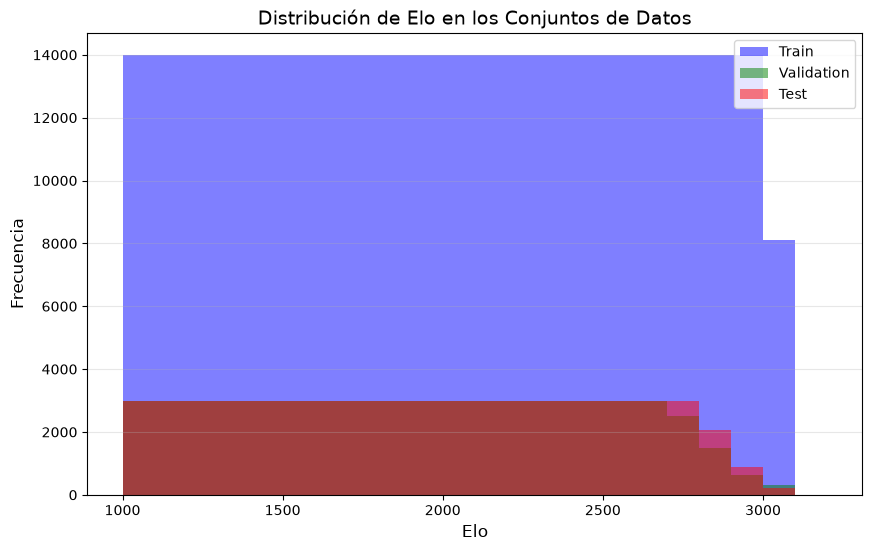

In [17]:
print("Generando histograma...")

plt.figure(figsize=(10, 6))

bins_compartidos = np.arange(1000, 3300, 100) 

plt.hist(train_elos, bins=bins_compartidos, alpha=0.5, density=False, label='Train', color='blue')
plt.hist(val_elos, bins=bins_compartidos, alpha=0.5, density=False, label='Validation', color='green')
plt.hist(test_elos, bins=bins_compartidos, alpha=0.5, density=False, label='Test', color='red')

plt.title('Distribución de Elo en los Conjuntos de Datos', fontsize=14)
plt.xlabel('Elo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Guarda la imagen en tu escritorio para usarla en la tesis
ruta_imagen = "../data/generado/graficos/distribucion_frecuencia_elo_data.png"
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
print(f"✅ Histograma guardado en: {ruta_imagen}")

plt.show()

✅ Histograma guardado en: ../data/generado/graficos/distribucion_proporcion_elo_data.png


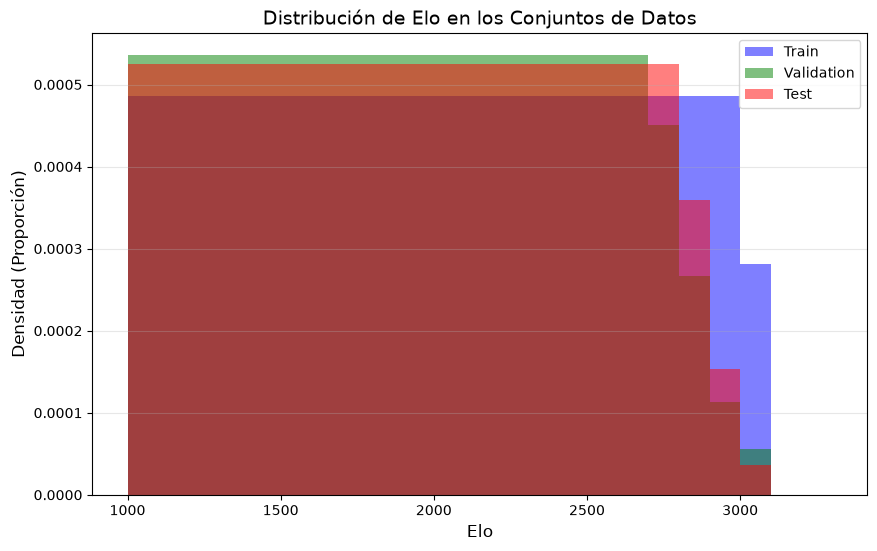

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(train_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Train', color='blue')
plt.hist(val_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Validation', color='green')
plt.hist(test_elos, bins=bins_compartidos, alpha=0.5, density=True, label='Test', color='red')

plt.title('Distribución de Elo en los Conjuntos de Datos', fontsize=14)
plt.xlabel('Elo', fontsize=12)
plt.ylabel('Densidad (Proporción)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Guarda la imagen en tu escritorio para usarla en la tesis
ruta_imagen = "../data/generado/graficos/distribucion_proporcion_elo_data.png"
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')
print(f"✅ Histograma guardado en: {ruta_imagen}")
